# Condition Shift Baseline Notebook

이 노트북은 `condition_shift_baseline` 실험을 실행하고 결과를 비교하기 위한 orchestrator다.

이 노트북에서 하는 일:

- Colab/서버에서 Git checkout과 dataset 준비 상태를 맞춘다.
- `PatchCore`, `UniVAD` runner를 `single` 또는 `sequential` 모드로 실행한다.
- 실행 결과로 남는 `summary.json`, `log.txt`, clean-eval artifact를 다시 읽는다.
- clean 재현성, shift 취약성, baseline 간 차이를 표와 heatmap으로 정리한다.

원칙:

- 실험 핵심 로직은 노트북 안이 아니라 versioned `.py` runner에 둔다.
- 노트북은 실행 흐름, 상태 확인, 결과 비교에 집중한다.
- 같은 노트북으로 `PatchCore -> UniVAD` 순차 실행과 사후 비교를 모두 처리한다.


## 경로 설정

Drive mount, repo root, report root 같은 공통 경로를 먼저 고정한다.


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
from pathlib import Path
from datetime import datetime
import importlib
import importlib.util
import site
import json
import subprocess
import sys
import threading
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
repo_candidates = [cwd, *cwd.parents, Path('/content/ReGraM')]
REPO_ROOT = next((p.resolve() for p in repo_candidates if p.exists() and p.name in {'ReGraM'}), cwd)
EXP_ROOT = REPO_ROOT / 'experiments' / 'validation' / 'condition_shift_baseline'
REPORT_ROOT = EXP_ROOT / 'reports'
NOTEBOOK_ROOT = EXP_ROOT / 'notebook'
MANIFEST_ROOT_CANDIDATES = [REPO_ROOT / 'manifests', EXP_ROOT / 'manifests']
SEVERITY_ORDER = {'low': 0, 'medium': 1, 'high': 2}
DEFAULT_PATCHCORE_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CORE_SRC = EXP_ROOT / 'src' / 'core'
if str(CORE_SRC) not in sys.path:
    sys.path.insert(0, str(CORE_SRC))

from augmentation_runtime import apply_augmentation
from patchcore_datasets import resolve_manifest_image_path


def now_string():
    return datetime.now().astimezone().strftime('%Y-%m-%d %H:%M:%S %Z')


def format_run_label(config):
    return f"{config['baseline']} / {config['category']}"


def display_title(title, body=None):
    text = f"## {title}"
    if body:
        text += f"\n\n{body}"
    display(Markdown(text))
def display_run_plan(run_configs):
    rows = []
    for idx, config in enumerate(run_configs, start=1):
        rows.append({
            'order': idx,
            'baseline': config['baseline'],
            'category': config['category'],
            'manifest_count': len(config['manifest_paths']),
            'summary_name': config['summary_path'].name,
            'device': config['device'],
            'wandb': 'on' if config.get('use_wandb') else 'off',
        })
    display(pd.DataFrame(rows))


def display_environment_summary():
    display_title('Environment Summary')
    display(pd.DataFrame([
        {'key': 'REPO_ROOT', 'value': str(REPO_ROOT)},
        {'key': 'EXP_ROOT', 'value': str(EXP_ROOT)},
        {'key': 'REPORT_ROOT', 'value': str(REPORT_ROOT)},
    ]))


def resolve_manifest_paths(manifest_names):
    manifest_paths = []
    for manifest_name in manifest_names:
        manifest_path = next(
            (root / manifest_name for root in MANIFEST_ROOT_CANDIDATES if (root / manifest_name).exists()),
            None,
        )
        if manifest_path is None:
            searched = [str(root / manifest_name) for root in MANIFEST_ROOT_CANDIDATES]
            raise FileNotFoundError(f'Manifest not found. searched={searched}')
        manifest_paths.append(manifest_path)
    return manifest_paths


def ensure_importable_path(path):
    path_str = str(Path(path).resolve())
    if path_str not in sys.path:
        sys.path.insert(0, path_str)
    importlib.invalidate_caches()
    for site_dir in site.getsitepackages():
        site.addsitedir(site_dir)
    user_site = site.getusersitepackages()
    if user_site:
        site.addsitedir(user_site)


def module_available(module_name, extra_paths=None):
    for extra_path in extra_paths or []:
        ensure_importable_path(extra_path)
    return importlib.util.find_spec(module_name) is not None


def stream_subprocess(command, cwd, show_output=True):
    process = subprocess.Popen(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        bufsize=1,
    )
    stdout_lines = []
    stderr_lines = []

    def pump(pipe, prefix, sink):
        try:
            for line in iter(pipe.readline, ''):
                if not line:
                    break
                sink.append(line)
                if show_output:
                    print(f"{prefix} {line.rstrip()}", flush=True)
        finally:
            pipe.close()

    stdout_thread = threading.Thread(target=pump, args=(process.stdout, '[stdout]', stdout_lines))
    stderr_thread = threading.Thread(target=pump, args=(process.stderr, '[stderr]', stderr_lines))
    stdout_thread.start()
    stderr_thread.start()
    returncode = process.wait()
    stdout_thread.join()
    stderr_thread.join()
    return {
        'returncode': returncode,
        'stdout': ''.join(stdout_lines),
        'stderr': ''.join(stderr_lines),
    }


def print_output_tail(name, text, tail_lines):
    lines = [line for line in text.splitlines() if line.strip()]
    if not lines:
        print(f"[{name}] <empty>")
        return
    tail = lines[-tail_lines:]
    print(f"[{name} tail] showing last {len(tail)} line(s)")
    for line in tail:
        print(line)


def ordered_baselines(values):
    seen = [value for value in dict.fromkeys(list(values)) if pd.notna(value)]
    preferred = globals().get('DASHBOARD_BASELINES', globals().get('REQUESTED_BASELINES', []))
    return [baseline for baseline in preferred if baseline in seen] + [baseline for baseline in seen if baseline not in preferred]


def display_df(title, df, empty_columns=None, body=None):
    display_title(title, body)
    if df is None or df.empty:
        display(pd.DataFrame(columns=empty_columns or []))
    else:
        display(df)


def draw_heatmap(ax, pivot, title, cmap='Blues', center=None, value_fmt='{:.2f}'):
    if pivot is None or pivot.empty:
        ax.set_title(title)
        ax.axis('off')
        return None

    values = pivot.to_numpy(dtype=float)
    if center is None:
        im = ax.imshow(values, aspect='auto', cmap=cmap)
    else:
        vmax = np.nanmax(np.abs(values)) if np.size(values) else 1.0
        vmax = 1.0 if not np.isfinite(vmax) or vmax == 0 else vmax
        im = ax.imshow(values, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)

    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(col) for col in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(idx) for idx in pivot.index])

    for row_idx in range(values.shape[0]):
        for col_idx in range(values.shape[1]):
            value = values[row_idx, col_idx]
            if np.isnan(value):
                text = '-'
            else:
                text = value_fmt.format(value)
            ax.text(col_idx, row_idx, text, ha='center', va='center', fontsize=8, color='black')

    return im


run_history = []

print('REPO_ROOT =', REPO_ROOT)
print('EXP_ROOT =', EXP_ROOT)


REPO_ROOT = /content/ReGraM
EXP_ROOT = /content/ReGraM/experiments/validation/condition_shift_baseline


## Git Checkout

Colab 런타임에서는 먼저 repo를 clone 또는 pull 해서 notebook이 호출할 runner와 helper 코드를 최신 상태로 맞춘다.

이 셀 이후부터는 `/content/ReGraM` 기준 경로를 사용한다.


In [30]:
REPO_URL = 'https://github.com/outSeop/ReGraM.git'
REPO_DIR = Path('/content/ReGraM')
git_cmd = (
    f'if [ -d "{REPO_DIR}/.git" ]; then git -C "{REPO_DIR}" pull --ff-only; '
    f'else git clone "{REPO_URL}" "{REPO_DIR}"; fi'
)
print(git_cmd)
subprocess.run(['bash', '-lc', git_cmd], check=True)

REPO_ROOT = REPO_DIR.resolve()
EXP_ROOT = REPO_ROOT / 'experiments' / 'validation' / 'condition_shift_baseline'
REPORT_ROOT = EXP_ROOT / 'reports'
NOTEBOOK_ROOT = EXP_ROOT / 'notebook'
MANIFEST_ROOT_CANDIDATES = [REPO_ROOT / 'manifests', EXP_ROOT / 'manifests']

print('updated REPO_ROOT =', REPO_ROOT)
print('updated EXP_ROOT =', EXP_ROOT)


if [ -d "/content/ReGraM/.git" ]; then git -C "/content/ReGraM" pull --ff-only; else git clone "https://github.com/outSeop/ReGraM.git" "/content/ReGraM"; fi
updated REPO_ROOT = /content/ReGraM
updated EXP_ROOT = /content/ReGraM/experiments/validation/condition_shift_baseline


## Dataset Load

LOCO raw dataset tar를 runtime으로 가져와서 runner가 바로 읽을 수 있는 위치에 푼다.


In [31]:
from pathlib import Path
import subprocess

drive_tar = Path("/content/drive/MyDrive/ReGraM/data/row/mvtec_loco_anomaly_detection.tar.gz")
runtime_tar = Path("/content/mvtec_loco_anomaly_detection.tar.gz")
runtime_row = Path("/content/ReGraM/data/row")
runtime_root = runtime_row / "mvtec_loco_anomaly_detection"

print("drive_tar exists:", drive_tar.exists())
print("runtime_root exists:", runtime_root.exists())

runtime_row.mkdir(parents=True, exist_ok=True)

if not runtime_root.exists():
    if not runtime_tar.exists():
        subprocess.run(["cp", str(drive_tar), str(runtime_tar)], check=True)
    subprocess.run(
        ["tar", "-xf", str(runtime_tar), "-C", str(runtime_row)],
        check=True,
    )

print("done")
print(runtime_root.exists(), runtime_root)


drive_tar exists: True
runtime_root exists: True
done
True /content/ReGraM/data/row/mvtec_loco_anomaly_detection


## Optional Dataset Bootstrap

Git checkout 이후 prepared dataset이나 보조 asset이 더 필요하면 별도 bootstrap script를 호출한다.

역할 분리:

- 코드 동기화: Git checkout 셀
- 데이터/보조 자산 준비: bootstrap 셀


In [32]:
bootstrap_cmd = [
    sys.executable,
    str(EXP_ROOT / 'colab' / 'bootstrap_runtime.py'),
    '--dry-run',
]
print(' '.join(bootstrap_cmd))
subprocess.run(bootstrap_cmd, cwd=REPO_ROOT, check=True)


/usr/bin/python3 /content/ReGraM/experiments/validation/condition_shift_baseline/colab/bootstrap_runtime.py --dry-run


CompletedProcess(args=['/usr/bin/python3', '/content/ReGraM/experiments/validation/condition_shift_baseline/colab/bootstrap_runtime.py', '--dry-run'], returncode=0)

## Experiment Control Center

이 아래 셀들은 baseline 선택, readiness 확인, 실행, 결과 비교를 하나의 실험 루프로 묶는다.

사용 흐름:

- config 셀에서 `RUN_MODE`, baseline 목록, category, manifest 범위를 정한다.
- setup 셀에서 baseline별 외부 repo, dependency, checkpoint, python module 상태를 점검한다.
- execution 셀에서 현재 queue를 순서대로 실행한다.
- result dashboard에서 누적 summary를 읽어 clean/shift 결과를 비교한다.


## Runner Config

여기서 이번 실행의 범위를 결정한다.

- `RUN_MODE = 'single'`: 특정 baseline 하나만 실행
- `RUN_MODE = 'sequential'`: `SEQUENTIAL_BASELINES` 순서대로 연속 실행
- `DASHBOARD_BASELINES`: 결과 대시보드가 읽을 baseline 목록
- `CATEGORIES`, `MANIFEST_NAMES`: 이번 실험 입력 범위


In [47]:
RUN_MODE = 'sequential'  # choose 'single' or 'sequential'
RUN_BASELINE = 'PatchCore'      # used only when RUN_MODE == 'single'
SEQUENTIAL_BASELINES = ['PatchCore', 'UniVAD']
DASHBOARD_BASELINES = ['PatchCore', 'UniVAD']
CATEGORIES = ['breakfast_box']
AUTO_DISCOVER_MANIFESTS = True
MANIFEST_NAMES = [
    'query_motion_blur.jsonl',
    'query_low_light.jsonl',
    'query_gaussian_noise.jsonl',
]
EXCLUDED_MANIFEST_NAMES = {'query_identity.jsonl', 'query_multi.jsonl'}
WANDB_PROJECT = 'regram-condition-shift'
WANDB_MODE = 'online'  # switch to online only after WANDB_API_KEY is configured
SHOW_RUNNER_OUTPUT = True
RUNNER_OUTPUT_TAIL_LINES = 40
RUN_ONLY_READY_BASELINES = True
STOP_ON_FAILURE = False
DOWNLOAD_MISSING_UNIVAD_CHECKPOINTS = False

BASELINE_SPECS = {
    'PatchCore': {
        'runner_name': 'PatchCore manifest shift evaluation',
        'runner_path': EXP_ROOT / 'src' / 'core' / 'run_patchcore_manifest_shift.py',
        'runner_inputs': 'category + manifest jsonl(s) + raw LOCO dataset root',
        'runner_outputs': 'single summary json per category under reports/patchcore_manifest_shift',
        'report_subdir': 'patchcore_manifest_shift',
        'external_dir': REPO_ROOT / 'external' / 'patchcore-inspection.clean',
        'external_repo_url': 'https://github.com/amazon-science/patchcore-inspection.git',
        'device': DEFAULT_PATCHCORE_DEVICE,
        'requires_cuda': False,
        'requires_checkpoints': False,
        'required_python_modules': [],
        'import_search_paths': [],
        'required_checkpoint_files': [],
        'checkpoint_download_urls': {},
        'use_wandb': True,
        'wandb_group': 'patchcore',
        'wandb_log_images': True,
        'wandb_max_images': 2,
        'extra_args': [],
        'notes': 'PatchCore runner consumes raw LOCO directly and falls back to CPU automatically.',
    },
    'UniVAD': {
        'runner_name': 'UniVAD manifest shift evaluation',
        'runner_path': EXP_ROOT / 'src' / 'univad' / 'run_manifest_shift.py',
        'runner_inputs': 'category + manifest jsonl(s) + raw LOCO dataset root',
        'runner_outputs': 'single summary json per category under reports/univad_manifest_shift',
        'report_subdir': 'univad_manifest_shift',
        'external_dir': REPO_ROOT / 'external' / 'UniVAD',
        'external_repo_url': 'https://github.com/FantasticGNU/UniVAD.git',
        'groundingdino_dir': REPO_ROOT / 'external' / 'UniVAD' / 'models' / 'GroundingDINO',
        'checkpoint_root': REPO_ROOT / 'external' / 'UniVAD' / 'pretrained_ckpts',
        'device': 'cuda',
        'requires_cuda': True,
        'requires_checkpoints': True,
        'required_python_modules': ['groundingdino'],
        'import_search_paths': [REPO_ROOT / 'external' / 'UniVAD' / 'models' / 'GroundingDINO'],
        'required_local_paths': [REPO_ROOT / 'external' / 'UniVAD' / 'models' / 'dinov2' / 'hubconf.py'],
        'required_checkpoint_files': [
            'sam_hq_vit_h.pth',
            'groundingdino_swint_ogc.pth',
        ],
        'checkpoint_download_urls': {
            'sam_hq_vit_h.pth': 'https://huggingface.co/lkeab/hq-sam/resolve/main/sam_hq_vit_h.pth',
            'groundingdino_swint_ogc.pth': 'https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth',
        },
        'use_wandb': True,
        'wandb_group': 'univad',
        'wandb_log_images': True,
        'wandb_max_images': 2,
        'extra_args': ['--image-size', '448', '--k-shot', '1', '--round', '0'],
        'notes': 'UniVAD needs CUDA, a recursive clone with the local dinov2 submodule, an editable GroundingDINO install, and local SAM/GroundingDINO checkpoints under pretrained_ckpts.',
    },
}

def validate_baseline_names(names, *, label):
    for baseline in names:
        if baseline not in BASELINE_SPECS:
            raise ValueError(f'Unknown {label} baseline={baseline}')

def resolve_requested_baselines(run_mode, run_baseline, sequential_baselines):
    if run_mode == 'single':
        if run_baseline not in BASELINE_SPECS:
            raise ValueError(f'Unknown RUN_BASELINE={run_baseline}')
        return [run_baseline]
    if run_mode == 'sequential':
        validate_baseline_names(sequential_baselines, label='sequential')
        return list(dict.fromkeys(sequential_baselines))
    raise ValueError(f'Unsupported RUN_MODE={run_mode}')

def collect_missing_checkpoint_files(spec):
    checkpoint_root = spec.get('checkpoint_root')
    if checkpoint_root is None:
        return []
    return [
        filename
        for filename in spec.get('required_checkpoint_files', [])
        if not (checkpoint_root / filename).exists()
    ]

validate_baseline_names(DASHBOARD_BASELINES, label='dashboard')
REQUESTED_BASELINES = resolve_requested_baselines(RUN_MODE, RUN_BASELINE, SEQUENTIAL_BASELINES)

if AUTO_DISCOVER_MANIFESTS:
    discovered = []
    for root in MANIFEST_ROOT_CANDIDATES:
        if root.exists():
            discovered.extend(path.name for path in sorted(root.glob('query_*.jsonl')))
    MANIFEST_NAMES = sorted({name for name in discovered if name not in EXCLUDED_MANIFEST_NAMES})

manifest_paths = resolve_manifest_paths(MANIFEST_NAMES)

def build_requested_run_configs(active_baselines):
    configs = []
    for baseline in active_baselines:
        spec = BASELINE_SPECS[baseline]
        for category in CATEGORIES:
            summary_path = REPORT_ROOT / spec['report_subdir'] / f'{category}_multi_all.json'
            log_path = REPORT_ROOT / spec['report_subdir'] / 'logs' / f'{category}_multi_all.log.txt'
            runner_cmd = [
                sys.executable,
                str(spec['runner_path']),
                '--category', category,
                '--manifest', *[str(p) for p in manifest_paths],
                '--device', spec['device'],
                *spec['extra_args'],
            ]
            if spec['use_wandb']:
                runner_cmd.extend([
                    '--use-wandb',
                    '--wandb-project', WANDB_PROJECT,
                    '--wandb-group', spec['wandb_group'],
                    '--wandb-mode', WANDB_MODE,
                ])
                if spec['wandb_log_images']:
                    runner_cmd.extend([
                        '--wandb-log-images',
                        '--wandb-max-images', str(spec['wandb_max_images']),
                    ])
            configs.append({
                'baseline': baseline,
                'category': category,
                'device': spec['device'],
                'manifest_paths': list(manifest_paths),
                'manifest_names': list(MANIFEST_NAMES),
                'summary_path': summary_path,
                'log_path': log_path,
                'runner_cmd': runner_cmd,
                'use_wandb': spec['use_wandb'],
                'runner_name': spec['runner_name'],
                'runner_path': spec['runner_path'],
                'runner_inputs': spec['runner_inputs'],
                'runner_outputs': spec['runner_outputs'],
                'wandb_group': spec['wandb_group'],
                'wandb_log_images': spec['wandb_log_images'],
                'wandb_max_images': spec['wandb_max_images'],
                'notes': spec['notes'],
            })
    return configs

def evaluate_baseline_readiness(active_baselines):
    import importlib.util as _importlib_util
    rows = []
    cuda_available = torch.cuda.is_available()
    for baseline in active_baselines:
        spec = BASELINE_SPECS[baseline]
        external_dir = spec['external_dir']
        repo_ready = external_dir.exists()
        checkpoint_root = spec.get('checkpoint_root')
        missing_checkpoint_files = collect_missing_checkpoint_files(spec)
        checkpoint_ready = len(missing_checkpoint_files) == 0
        missing_local_paths = [str(path) for path in spec.get('required_local_paths', []) if not Path(path).exists()]
        local_paths_ready = len(missing_local_paths) == 0
        cuda_ready = cuda_available if spec.get('requires_cuda') else True
        for import_path in spec.get('import_search_paths', []):
            ensure_importable_path(import_path)
        missing_modules = [
            module_name
            for module_name in spec.get('required_python_modules', [])
            if _importlib_util.find_spec(module_name) is None
        ]
        python_modules_ready = len(missing_modules) == 0
        ready = repo_ready and checkpoint_ready and local_paths_ready and cuda_ready and python_modules_ready
        blockers = []
        if not repo_ready:
            blockers.append('external_repo_missing')
        if spec.get('requires_cuda') and not cuda_ready:
            blockers.append('cuda_unavailable')
        if not local_paths_ready:
            blockers.append('local_dependency_missing:' + ','.join(Path(path).name for path in missing_local_paths))
        if spec.get('requires_checkpoints') and not checkpoint_ready:
            blockers.append('checkpoint_missing:' + ','.join(missing_checkpoint_files))
        if missing_modules:
            blockers.append('python_module_missing:' + ','.join(missing_modules))
        rows.append({
            'baseline': baseline,
            'requested': True,
            'device': spec['device'],
            'external_repo_exists': repo_ready,
            'cuda_required': spec.get('requires_cuda', False),
            'cuda_available': cuda_available,
            'checkpoint_required': spec.get('requires_checkpoints', False),
            'checkpoint_root': str(checkpoint_root) if checkpoint_root else '',
            'checkpoint_ready': checkpoint_ready,
            'missing_checkpoint_files': ', '.join(missing_checkpoint_files) if missing_checkpoint_files else '-',
            'missing_local_paths': ', '.join(missing_local_paths) if missing_local_paths else '-',
            'required_python_modules': ', '.join(spec.get('required_python_modules', [])) or '-',
            'python_modules_ready': python_modules_ready,
            'ready': ready,
            'blockers': ', '.join(blockers) if blockers else 'ready',
            'notes': spec['notes'],
        })
    return pd.DataFrame(rows)

requested_run_configs = build_requested_run_configs(REQUESTED_BASELINES)
dashboard_run_configs = build_requested_run_configs(DASHBOARD_BASELINES)
baseline_status_df = evaluate_baseline_readiness(REQUESTED_BASELINES)
run_configs = list(requested_run_configs)
skipped_run_configs = []

display_title(
    'Experiment Preset',
    f'RUN_MODE=`{RUN_MODE}` | requested baselines=`{", ".join(REQUESTED_BASELINES)}` | dashboard baselines=`{", ".join(DASHBOARD_BASELINES)}`',
)
display(pd.DataFrame([
    {
        'run_mode': RUN_MODE,
        'requested_baselines': ', '.join(REQUESTED_BASELINES),
        'dashboard_baselines': ', '.join(DASHBOARD_BASELINES),
        'category_count': len(CATEGORIES),
        'manifest_count': len(MANIFEST_NAMES),
        'wandb_mode': WANDB_MODE,
        'stop_on_failure': STOP_ON_FAILURE,
        'download_missing_univad_checkpoints': DOWNLOAD_MISSING_UNIVAD_CHECKPOINTS,
    }
]))
display(pd.DataFrame([
    {
        'baseline': baseline,
        'runner_name': BASELINE_SPECS[baseline]['runner_name'],
        'device': BASELINE_SPECS[baseline]['device'],
        'wandb_group': BASELINE_SPECS[baseline]['wandb_group'] if BASELINE_SPECS[baseline]['use_wandb'] else 'off',
        'wandb_mode': WANDB_MODE if BASELINE_SPECS[baseline]['use_wandb'] else 'disabled',
        'runner_outputs': BASELINE_SPECS[baseline]['runner_outputs'],
        'notes': BASELINE_SPECS[baseline]['notes'],
    }
    for baseline in REQUESTED_BASELINES
]))
display(pd.DataFrame({'manifest_name': MANIFEST_NAMES}))
display_run_plan(requested_run_configs)


## Experiment Preset

RUN_MODE=`sequential` | requested baselines=`PatchCore, UniVAD` | dashboard baselines=`PatchCore, UniVAD`

,run_mode,requested_baselines,dashboard_baselines,category_count,manifest_count,wandb_mode,stop_on_failure,download_missing_univad_checkpoints
0,sequential,"PatchCore, UniVAD","PatchCore, UniVAD",1,8,online,False,False


,baseline,runner_name,device,wandb_group,wandb_mode,runner_outputs,notes
0,PatchCore,PatchCore manifest shift evaluation,cuda,patchcore,online,single summary json per category under reports...,PatchCore runner consumes raw LOCO directly an...
1,UniVAD,UniVAD manifest shift evaluation,cuda,univad,online,single summary json per category under reports...,"UniVAD needs CUDA, an editable GroundingDINO i..."


,manifest_name
0,query_brightness.jsonl
1,query_compression.jsonl
2,query_gaussian_blur.jsonl
3,query_gaussian_noise.jsonl
4,query_low_light.jsonl
5,query_low_resolution.jsonl
6,query_motion_blur.jsonl
7,query_position_shift.jsonl


,order,baseline,category,manifest_count,summary_name,device,wandb
0,1,PatchCore,breakfast_box,8,breakfast_box_multi_all.json,cuda,on
1,2,UniVAD,breakfast_box,8,breakfast_box_multi_all.json,cuda,on


In [48]:
display_title('Current Run Matrix', 'Single mode executes one baseline. Sequential mode executes the listed baselines in order and keeps a shared comparison dashboard.')
command_preview_df = pd.DataFrame([
    {
        'baseline': config['baseline'],
        'category': config['category'],
        'manifest_count': len(config['manifest_paths']),
        'device': config['device'],
        'summary_name': config['summary_path'].name,
        'log_name': config['log_path'].name,
        'runner_cmd': ' '.join(config['runner_cmd']),
    }
    for config in requested_run_configs
])
display(command_preview_df)


## Current Run Matrix

Single mode executes one baseline. Sequential mode executes the listed baselines in order and keeps a shared comparison dashboard.

,baseline,category,manifest_count,device,summary_name,log_name,runner_cmd
0,PatchCore,breakfast_box,8,cuda,breakfast_box_multi_all.json,breakfast_box_multi_all.log.txt,/usr/bin/python3 /content/ReGraM/experiments/v...
1,UniVAD,breakfast_box,8,cuda,breakfast_box_multi_all.json,breakfast_box_multi_all.log.txt,/usr/bin/python3 /content/ReGraM/experiments/v...


In [50]:
display_title(
    'Baseline Setup & Readiness',
    'Prepare every baseline in REQUESTED_BASELINES. In sequential mode the setup and readiness check also follow that order.',
)

external_root = REPO_ROOT / 'external'
external_root.mkdir(parents=True, exist_ok=True)

def ensure_git_repo(repo_dir: Path, repo_url: str, *, recurse_submodules=False):
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    clone_flag = '--recurse-submodules ' if recurse_submodules else ''
    subprocess.run(
        [
            'bash', '-lc',
            f'test -d "{repo_dir}/.git" || git clone {clone_flag}"{repo_url}" "{repo_dir}"'
        ],
        check=True,
    )
    if recurse_submodules:
        subprocess.run(['git', '-C', str(repo_dir), 'submodule', 'update', '--init', '--recursive'], check=True)

def ensure_editable_package(package_dir: Path):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(package_dir)], check=True)

def ensure_directory(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def download_file(url: str, destination: Path):
    ensure_directory(destination.parent)
    subprocess.run(['curl', '-L', '--fail', '-o', str(destination), url], check=True)

def build_local_dependency_status_rows(spec):
    rows = []
    for path in spec.get('required_local_paths', []):
        rows.append({
            'baseline': 'UniVAD',
            'required_path': str(path),
            'exists': Path(path).exists(),
            'path': str(path),
        })
    return rows

def build_checkpoint_status_rows(spec):
    checkpoint_root = spec.get('checkpoint_root')
    rows = []
    if checkpoint_root is None:
        return rows
    for filename in spec.get('required_checkpoint_files', []):
        rows.append({
            'baseline': 'UniVAD',
            'checkpoint_file': filename,
            'exists': (checkpoint_root / filename).exists(),
            'path': str(checkpoint_root / filename),
        })
    return rows

def maybe_download_univad_checkpoints(spec):
    checkpoint_root = spec['checkpoint_root']
    ensure_directory(checkpoint_root)
    downloaded = []
    if not DOWNLOAD_MISSING_UNIVAD_CHECKPOINTS:
        return downloaded
    for filename in collect_missing_checkpoint_files(spec):
        url = spec['checkpoint_download_urls'].get(filename)
        if not url:
            continue
        destination = checkpoint_root / filename
        print(f'download checkpoint: {filename} <- {url}')
        download_file(url, destination)
        downloaded.append(filename)
    return downloaded

def setup_patchcore(spec):
    patchcore_dir = spec['external_dir']
    ensure_git_repo(patchcore_dir, spec['external_repo_url'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'faiss-cpu', 'timm'], check=True)
    return {
        'baseline': 'PatchCore',
        'external_dir': str(patchcore_dir),
        'setup_status': 'ready',
        'note': 'Repo synced and lightweight runtime deps installed.',
    }

def setup_univad(spec):
    import importlib.util as _importlib_util
    univad_dir = spec['external_dir']
    ensure_git_repo(univad_dir, spec['external_repo_url'], recurse_submodules=True)
    requirements_path = univad_dir / 'requirements.txt'
    groundingdino_dir = spec['groundingdino_dir']
    checkpoint_root = spec['checkpoint_root']
    missing_local_paths = [str(path) for path in spec.get('required_local_paths', []) if not Path(path).exists()]
    ensure_directory(checkpoint_root)
    if requirements_path.exists():
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)], check=True)
        requirement_note = 'requirements.txt installed'
    else:
        requirement_note = 'requirements.txt not found; using current runtime packages'
    ensure_editable_package(groundingdino_dir)
    ensure_importable_path(groundingdino_dir)
    downloaded_checkpoint_files = maybe_download_univad_checkpoints(spec)
    missing_checkpoint_files = collect_missing_checkpoint_files(spec)
    return {
        'baseline': 'UniVAD',
        'external_dir': str(univad_dir),
        'groundingdino_dir': str(groundingdino_dir),
        'checkpoint_root': str(checkpoint_root),
        'groundingdino_importable': module_available('groundingdino', extra_paths=[groundingdino_dir]),
        'missing_local_paths': ', '.join(missing_local_paths) if missing_local_paths else '-',
        'download_missing_checkpoints': DOWNLOAD_MISSING_UNIVAD_CHECKPOINTS,
        'downloaded_checkpoint_files': ', '.join(downloaded_checkpoint_files) if downloaded_checkpoint_files else '-',
        'missing_checkpoint_files': ', '.join(missing_checkpoint_files) if missing_checkpoint_files else '-',
        'setup_status': 'repo_synced',
        'note': requirement_note,
    }

def setup_baseline(baseline):
    spec = BASELINE_SPECS[baseline]
    if baseline == 'PatchCore':
        return setup_patchcore(spec)
    if baseline == 'UniVAD':
        return setup_univad(spec)
    raise ValueError(f'Unsupported baseline setup={baseline}')

setup_rows = [setup_baseline(baseline) for baseline in REQUESTED_BASELINES]
if setup_rows:
    display(pd.DataFrame(setup_rows))

if 'UniVAD' in REQUESTED_BASELINES:
    display_title('UniVAD Local Dependency Status', 'These are the local repo paths that readiness treats as required for UniVAD execution, including the dinov2 submodule files.')
    display(pd.DataFrame(build_local_dependency_status_rows(BASELINE_SPECS['UniVAD'])))
    display_title('UniVAD Checkpoint Status', 'These are the local checkpoint files that readiness treats as required for UniVAD execution.')
    display(pd.DataFrame(build_checkpoint_status_rows(BASELINE_SPECS['UniVAD'])))

baseline_status_df = evaluate_baseline_readiness(REQUESTED_BASELINES)
ready_baselines = baseline_status_df.loc[baseline_status_df['ready'], 'baseline'].tolist()
if RUN_ONLY_READY_BASELINES:
    run_configs = [config for config in requested_run_configs if config['baseline'] in ready_baselines]
    skipped_run_configs = [config for config in requested_run_configs if config['baseline'] not in ready_baselines]
else:
    run_configs = list(requested_run_configs)
    skipped_run_configs = []

baseline_status_df['will_run'] = baseline_status_df['baseline'].isin({config['baseline'] for config in run_configs})

display_title('Baseline Readiness', 'Sequential mode will execute only the baselines that pass readiness. For UniVAD, the blockers column now lists the exact missing checkpoint files.')
display(baseline_status_df)

if skipped_run_configs:
    display_title('Skipped Runs', 'Requested baselines that did not pass readiness are listed here and removed from the execution queue.')
    display(pd.DataFrame([
        {
            'baseline': config['baseline'],
            'category': config['category'],
            'summary_path': str(config['summary_path']),
            'log_path': str(config['log_path']),
        }
        for config in skipped_run_configs
    ]))

display_title('Execution Queue', f'Prepared `{len(run_configs)}` runnable jobs in baseline order: `{", ".join([config["baseline"] for config in run_configs])}`')
display_run_plan(run_configs)


## Baseline Setup & Readiness

Prepare every baseline in REQUESTED_BASELINES. In sequential mode the setup and readiness check also follow that order.

,baseline,external_dir,setup_status,note,groundingdino_dir,checkpoint_root,groundingdino_importable,download_missing_checkpoints,downloaded_checkpoint_files,missing_checkpoint_files
0,PatchCore,/content/ReGraM/external/patchcore-inspection....,ready,Repo synced and lightweight runtime deps insta...,NaN,NaN,NaN,NaN,NaN,NaN
1,UniVAD,/content/ReGraM/external/UniVAD,repo_synced,requirements.txt installed,/content/ReGraM/external/UniVAD/models/Groundi...,/content/ReGraM/external/UniVAD/pretrained_ckpts,True,False,-,-


## UniVAD Checkpoint Status

These are the local checkpoint files that readiness treats as required for UniVAD execution.

,baseline,checkpoint_file,exists,path
0,UniVAD,sam_hq_vit_h.pth,True,/content/ReGraM/external/UniVAD/pretrained_ckp...
1,UniVAD,groundingdino_swint_ogc.pth,True,/content/ReGraM/external/UniVAD/pretrained_ckp...


## Baseline Readiness

Sequential mode will execute only the baselines that pass readiness. For UniVAD, the blockers column now lists the exact missing checkpoint files.

,baseline,requested,device,external_repo_exists,cuda_required,cuda_available,checkpoint_required,checkpoint_root,checkpoint_ready,missing_checkpoint_files,required_python_modules,python_modules_ready,ready,blockers,notes,will_run
0,PatchCore,True,cuda,True,False,True,False,,True,-,-,True,True,ready,PatchCore runner consumes raw LOCO directly an...,True
1,UniVAD,True,cuda,True,True,True,True,/content/ReGraM/external/UniVAD/pretrained_ckpts,True,-,groundingdino,True,True,ready,"UniVAD needs CUDA, an editable GroundingDINO i...",True


## Execution Queue

Prepared `2` runnable jobs in baseline order: `PatchCore, UniVAD`

,order,baseline,category,manifest_count,summary_name,device,wandb
0,1,PatchCore,breakfast_box,8,breakfast_box_multi_all.json,cuda,on
1,2,UniVAD,breakfast_box,8,breakfast_box_multi_all.json,cuda,on


In [51]:
run_history = []
total_runs = len(run_configs)
if total_runs == 0:
    display_title('Execution Log', 'No runnable jobs are queued. Check the readiness table above.')
else:
    display_title('Execution Log', f'Started at `{now_string()}` with `{total_runs}` scheduled runs.')

    for idx, config in enumerate(run_configs, start=1):
        label = format_run_label(config)
        started_at = now_string()
        print('=' * 100)
        print(f"[{idx}/{total_runs}] START {label} @ {started_at}")
        print('summary_path =', config['summary_path'])
        print('log_path =', config['log_path'])
        print('command =', ' '.join(config['runner_cmd']))
        tic = time.perf_counter()
        result = stream_subprocess(
            config['runner_cmd'],
            cwd=REPO_ROOT,
            show_output=SHOW_RUNNER_OUTPUT,
        )
        elapsed_sec = round(time.perf_counter() - tic, 2)
        status = 'success' if result['returncode'] == 0 else 'failed'
        finished_at = now_string()
        summary_exists = Path(config['summary_path']).exists()
        log_exists = Path(config['log_path']).exists()
        run_history.append({
            'order': idx,
            'baseline': config['baseline'],
            'category': config['category'],
            'status': status,
            'returncode': result['returncode'],
            'elapsed_sec': elapsed_sec,
            'started_at': started_at,
            'finished_at': finished_at,
            'summary_exists': summary_exists,
            'log_exists': log_exists,
            'summary_path': str(config['summary_path']),
            'log_path': str(config['log_path']),
        })
        print(f"[{idx}/{total_runs}] END   {label} -> {status} ({elapsed_sec}s) @ {finished_at}")
        if result['returncode'] != 0:
            print('-' * 100)
            print(f"Failure recap for {label}")
            print_output_tail('stderr', result['stderr'], tail_lines=RUNNER_OUTPUT_TAIL_LINES)
            if result['stdout'].strip():
                print_output_tail('stdout', result['stdout'], tail_lines=min(20, RUNNER_OUTPUT_TAIL_LINES))
            if log_exists:
                print(f"runner log file = {config['log_path']}")
            if STOP_ON_FAILURE:
                display(pd.DataFrame(run_history))
                raise RuntimeError(
                    f"runner failed for {label}; inspect the streamed [stdout]/[stderr] lines above"
                )

    print('=' * 100)
    display_title('Execution Summary', f'Finished at `{now_string()}`.')
    display(pd.DataFrame(run_history))

    failed_runs = [row for row in run_history if row['status'] == 'failed']
    if failed_runs and not STOP_ON_FAILURE:
        display_title('Execution Failures', f'`{len(failed_runs)}` run(s) failed. Successful summaries can still be compared below.')
        display(pd.DataFrame(failed_runs))


## Execution Log

Started at `2026-04-22 18:36:08 UTC` with `2` scheduled runs.

[1/2] START PatchCore / breakfast_box @ 2026-04-22 18:36:08 UTC
summary_path = /content/ReGraM/experiments/validation/condition_shift_baseline/reports/patchcore_manifest_shift/breakfast_box_multi_all.json
log_path = /content/ReGraM/experiments/validation/condition_shift_baseline/reports/patchcore_manifest_shift/logs/breakfast_box_multi_all.log.txt
command = /usr/bin/python3 /content/ReGraM/experiments/validation/condition_shift_baseline/src/core/run_patchcore_manifest_shift.py --category breakfast_box --manifest /content/ReGraM/manifests/query_brightness.jsonl /content/ReGraM/manifests/query_compression.jsonl /content/ReGraM/manifests/query_gaussian_blur.jsonl /content/ReGraM/manifests/query_gaussian_noise.jsonl /content/ReGraM/manifests/query_low_light.jsonl /content/ReGraM/manifests/query_low_resolution.jsonl /content/ReGraM/manifests/query_motion_blur.jsonl /content/ReGraM/manifests/query_position_shift.jsonl --device cuda --use-wandb --wandb-project regram-condition-shift --wandb-g

## Execution Summary

Finished at `2026-04-22 18:48:35 UTC`.

,order,baseline,category,status,returncode,elapsed_sec,started_at,finished_at,summary_exists,log_exists,summary_path,log_path
0,1,PatchCore,breakfast_box,success,0,672.02,2026-04-22 18:36:08 UTC,2026-04-22 18:47:20 UTC,True,True,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...
1,2,UniVAD,breakfast_box,failed,1,75.68,2026-04-22 18:47:20 UTC,2026-04-22 18:48:35 UTC,False,False,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...


## Execution Failures

`1` run(s) failed. Successful summaries can still be compared below.

,order,baseline,category,status,returncode,elapsed_sec,started_at,finished_at,summary_exists,log_exists,summary_path,log_path
0,2,UniVAD,breakfast_box,failed,1,75.68,2026-04-22 18:47:20 UTC,2026-04-22 18:48:35 UTC,False,False,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...


## Result Dashboard

이 아래 셀들은 runner가 남긴 artifact를 다시 읽어서, clean 기준 성능과 shift 취약성을 실험 리포트처럼 정리한다.

읽는 대상:

- manifest-shift `summary.json`
- clean-eval artifact
- identity reproduction / manifest validation artifact

보는 관점:

- clean data에 대한 재현성과 기준 성능
- shift data에서 severity별, family별 붕괴 패턴
- PatchCore와 UniVAD의 상대 우위와 약점 차이

중요:

- dashboard는 `DASHBOARD_BASELINES`에 포함된 누적 결과를 함께 읽는다.
- 따라서 오늘 `PatchCore`만 돌리고, 나중에 `UniVAD`를 돌려도 같은 표와 heatmap에서 같이 비교할 수 있다.


In [42]:
TOP_K_WORST_SHIFTS = 10


def load_json_if_exists(path):
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None


def first_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def safe_mean(values):
    return float(np.mean(values)) if values else np.nan


def safe_max(values):
    return float(max(values)) if values else np.nan


def normalize_patchcore_clean_eval(payload, source_path):
    raw = payload.get('payload', payload)
    rows = []
    for item in raw.get('categories', []):
        rows.append({
            'baseline': 'PatchCore',
            'category': item.get('category'),
            'clean_metric_primary_name': 'image_auroc',
            'clean_metric_primary': item.get('image_auroc'),
            'clean_metric_secondary_name': 'full_pixel_auroc',
            'clean_metric_secondary': item.get('full_pixel_auroc'),
            'clean_metric_tertiary_name': 'anomaly_pixel_auroc',
            'clean_metric_tertiary': item.get('anomaly_pixel_auroc'),
            'train_count': item.get('train_count'),
            'test_count': item.get('test_count'),
            'artifact_path': str(source_path),
        })
    return rows


def normalize_univad_clean_eval(payload, source_path):
    metrics = payload.get('metrics', {})
    return [{
        'baseline': payload.get('baseline', 'UniVAD'),
        'category': payload.get('class_name'),
        'clean_metric_primary_name': 'class_auroc_sp_percent',
        'clean_metric_primary': metrics.get('class_auroc_sp_percent'),
        'clean_metric_secondary_name': 'class_auroc_px_percent',
        'clean_metric_secondary': metrics.get('class_auroc_px_percent'),
        'clean_metric_tertiary_name': 'mean_auroc_sp_percent',
        'clean_metric_tertiary': metrics.get('mean_auroc_sp_percent'),
        'train_count': None,
        'test_count': None,
        'artifact_path': str(source_path),
    }]


def load_clean_eval_rows(baseline, category):
    if baseline == 'PatchCore':
        candidates = [
            REPORT_ROOT / f'patchcore_clean_eval_{category}.json',
            REPORT_ROOT / 'patchcore_clean_eval.json',
        ]
    elif baseline == 'UniVAD':
        candidates = [
            REPORT_ROOT / 'univad_clean_eval' / f'{category}.json',
        ]
    else:
        candidates = []

    source_path = first_existing_path(candidates)
    if source_path is None:
        return [], None

    payload = load_json_if_exists(source_path)
    if payload is None:
        return [], source_path

    if baseline == 'PatchCore':
        return normalize_patchcore_clean_eval(payload, source_path), source_path
    if baseline == 'UniVAD':
        return normalize_univad_clean_eval(payload, source_path), source_path
    return [], source_path


def load_identity_repro_rows(baseline, category):
    if baseline == 'PatchCore':
        candidates = [REPORT_ROOT / 'patchcore_identity_repro' / f'{category}.json']
    else:
        candidates = []

    source_path = first_existing_path(candidates)
    if source_path is None:
        return [], None

    payload = load_json_if_exists(source_path)
    if payload is None:
        return [], source_path

    score_diff = payload.get('score_diff', {})
    return [{
        'baseline': baseline,
        'category': payload.get('category', category),
        'identity_mean_abs_diff': score_diff.get('mean_abs_diff'),
        'identity_max_abs_diff': score_diff.get('max_abs_diff'),
        'identity_allclose_atol_1e6': score_diff.get('allclose_atol_1e-6'),
        'identity_allclose_atol_1e5': score_diff.get('allclose_atol_1e-5'),
        'direct_clean_mean': (payload.get('direct_clean') or {}).get('mean'),
        'manifest_identity_mean': (payload.get('manifest_identity') or {}).get('mean'),
        'artifact_path': str(source_path),
    }], source_path


summary_sources = dashboard_run_configs if 'dashboard_run_configs' in globals() else (requested_run_configs if 'requested_run_configs' in globals() else run_configs)
shift_rows = []
clean_manifest_rows = []
corruption_summary_rows = []
scoreboard_rows = []
missing_summary_rows = []
artifact_status_rows = []
clean_eval_rows = []
identity_repro_rows = []
distribution_rows = []
gallery_rows = []

for config in summary_sources:
    summary_path = config['summary_path']
    summary_exists = summary_path.exists()
    artifact_status_rows.append({
        'baseline': config['baseline'],
        'category': config['category'],
        'artifact_type': 'manifest_summary',
        'exists': summary_exists,
        'path': str(summary_path),
    })
    if not summary_exists:
        missing_summary_rows.append({
            'baseline': config['baseline'],
            'category': config['category'],
            'summary_path': str(summary_path),
            'log_path': str(config['log_path']),
        })
        continue

    summary = load_json_if_exists(summary_path)
    metrics = summary.get('metrics', {})
    payload = summary.get('payload', {})
    clean_good = payload.get('clean_good', {})
    clean_anomaly = payload.get('clean_anomaly', {})
    clean_scores = payload.get('clean_score_distributions', {})
    clean_normal_scores = [float(value) for value in clean_scores.get('clean_normal_scores', [])]
    clean_anomaly_scores = [float(value) for value in clean_scores.get('clean_anomaly_scores', [])]
    clean_image_auroc = metrics.get('clean_image_auroc')
    baseline = summary['baseline']
    category = summary['class_name']

    clean_manifest_rows.append({
        'baseline': baseline,
        'category': category,
        'clean_image_auroc': clean_image_auroc,
        'clean_good_mean': metrics.get('clean_good_mean', clean_good.get('mean')),
        'clean_good_median': metrics.get('clean_good_median', clean_good.get('median')),
        'clean_anomaly_mean': metrics.get('clean_anomaly_mean', clean_anomaly.get('mean')),
        'clean_anomaly_median': metrics.get('clean_anomaly_median', clean_anomaly.get('median')),
        'summary_path': str(summary_path),
    })

    cell_rows = []
    severity_spec_by_cell = payload.get('severity_spec_by_cell', {})
    for aug_type, severity_map in payload.get('augmentations', {}).items():
        for severity, item in severity_map.items():
            cell_key = f'{aug_type}/{severity}'
            spec = severity_spec_by_cell.get(cell_key, payload.get('severity_spec', {}))
            shifted_image_auroc = item.get('shifted_image_auroc', item.get('image_auroc_vs_clean_anomaly'))
            image_auroc_drop_from_clean = item.get('image_auroc_drop_from_clean')
            if image_auroc_drop_from_clean is None and shifted_image_auroc is not None and clean_image_auroc is not None:
                image_auroc_drop_from_clean = clean_image_auroc - shifted_image_auroc
            shifted_normal_fpr = item.get('shifted_normal_fpr', item.get('fpr_over_clean_max'))
            shifted_normal_scores = [float(value) for value in item.get('shifted_normal_scores', [])]
            row = {
                'baseline': baseline,
                'category': category,
                'shift_family': aug_type,
                'severity': severity,
                'severity_rank': SEVERITY_ORDER.get(severity, 999),
                'cell_key': cell_key,
                'shifted_normal_mean': item.get('shifted_normal_mean', item.get('mean')),
                'shifted_normal_median': item.get('shifted_normal_median', item.get('median')),
                'shifted_normal_p25': item.get('p25'),
                'shifted_normal_p75': item.get('p75'),
                'shifted_normal_fpr': shifted_normal_fpr,
                'shifted_image_auroc': shifted_image_auroc,
                'image_auroc_drop_from_clean': image_auroc_drop_from_clean,
                'mean_score_shift': item.get('mean_score_shift'),
                'median_score_shift': item.get('median_score_shift'),
                'shifted_normal_scores': shifted_normal_scores,
                **{f'severity_param_{k}': v for k, v in spec.items()},
            }
            shift_rows.append(row)
            cell_rows.append(row)
            distribution_rows.append({
                'baseline': baseline,
                'category': category,
                'shift_family': aug_type,
                'severity': severity,
                'severity_rank': SEVERITY_ORDER.get(severity, 999),
                'clean_normal_scores': clean_normal_scores,
                'clean_anomaly_scores': clean_anomaly_scores,
                'shifted_normal_scores': shifted_normal_scores,
            })
            for sample in item.get('sample_rows', []):
                gallery_rows.append({
                    'baseline': baseline,
                    'category': category,
                    'shift_family': aug_type,
                    'severity': severity,
                    'severity_rank': SEVERITY_ORDER.get(severity, 999),
                    'image_path': sample.get('image_path'),
                    'image_name': sample.get('image_name'),
                    'source_id': sample.get('source_id'),
                    'score': sample.get('score'),
                    'score_delta_from_clean_mean': sample.get('score_delta_from_clean_mean'),
                    'augmentation_type': sample.get('augmentation_type', aug_type),
                    'seed': sample.get('seed'),
                    'params': json.dumps(sample.get('params', {}), ensure_ascii=True, sort_keys=True),
                    'params_dict': sample.get('params', {}),
                })

    if cell_rows:
        fpr_values = [row['shifted_normal_fpr'] for row in cell_rows if pd.notna(row['shifted_normal_fpr'])]
        auroc_drop_values = [row['image_auroc_drop_from_clean'] for row in cell_rows if pd.notna(row['image_auroc_drop_from_clean'])]
        mean_shift_values = [row['mean_score_shift'] for row in cell_rows if pd.notna(row['mean_score_shift'])]
        median_shift_values = [row['median_score_shift'] for row in cell_rows if pd.notna(row['median_score_shift'])]
        worst_fpr_cell = max(cell_rows, key=lambda row: row['shifted_normal_fpr'] if pd.notna(row['shifted_normal_fpr']) else -1.0)
        worst_drop_cell = max(cell_rows, key=lambda row: row['image_auroc_drop_from_clean'] if pd.notna(row['image_auroc_drop_from_clean']) else -1.0)
        scoreboard_rows.append({
            'baseline': baseline,
            'category': category,
            'clean_image_auroc': clean_image_auroc,
            'mean_shifted_normal_fpr': metrics.get('mean_shifted_normal_fpr', safe_mean(fpr_values)),
            'worst_shifted_normal_fpr': metrics.get('worst_shifted_normal_fpr', safe_max(fpr_values)),
            'worst_fpr_cell': metrics.get('worst_shift_cell_by_fpr', worst_fpr_cell.get('cell_key')),
            'mean_image_auroc_drop_from_clean': metrics.get('mean_image_auroc_drop_from_clean', safe_mean(auroc_drop_values)),
            'worst_image_auroc_drop_from_clean': metrics.get('worst_image_auroc_drop_from_clean', safe_max(auroc_drop_values)),
            'worst_auroc_drop_cell': metrics.get('worst_shift_cell_by_auroc_drop', worst_drop_cell.get('cell_key')),
            'mean_score_shift': metrics.get('mean_score_shift', safe_mean(mean_shift_values)),
            'mean_median_score_shift': metrics.get('mean_median_score_shift', safe_mean(median_shift_values)),
            'summary_path': str(summary_path),
        })

for baseline in ordered_baselines(DASHBOARD_BASELINES):
    for category in CATEGORIES:
        clean_rows, clean_source = load_clean_eval_rows(baseline, category)
        artifact_status_rows.append({
            'baseline': baseline,
            'category': category,
            'artifact_type': 'clean_eval',
            'exists': clean_source is not None,
            'path': str(clean_source) if clean_source else '',
        })
        clean_eval_rows.extend(clean_rows)

        identity_rows, identity_source = load_identity_repro_rows(baseline, category)
        artifact_status_rows.append({
            'baseline': baseline,
            'category': category,
            'artifact_type': 'identity_repro',
            'exists': identity_source is not None,
            'path': str(identity_source) if identity_source else '',
        })
        identity_repro_rows.extend(identity_rows)

shift_df = pd.DataFrame(shift_rows)
if not shift_df.empty:
    shift_df = shift_df.sort_values(['baseline', 'category', 'shift_family', 'severity_rank']).reset_index(drop=True)

clean_manifest_df = pd.DataFrame(clean_manifest_rows)
if not clean_manifest_df.empty:
    clean_manifest_df = clean_manifest_df.sort_values(['baseline', 'category']).reset_index(drop=True)

scoreboard_df = pd.DataFrame(scoreboard_rows)
if not scoreboard_df.empty:
    scoreboard_df = scoreboard_df.sort_values(['baseline', 'category']).reset_index(drop=True)

if not shift_df.empty:
    corruption_summary_df = shift_df.groupby(['baseline', 'category', 'shift_family']).agg(
        mean_shifted_normal_fpr=('shifted_normal_fpr', 'mean'),
        worst_shifted_normal_fpr=('shifted_normal_fpr', 'max'),
        mean_image_auroc_drop_from_clean=('image_auroc_drop_from_clean', 'mean'),
        worst_image_auroc_drop_from_clean=('image_auroc_drop_from_clean', 'max'),
        mean_score_shift=('mean_score_shift', 'mean'),
        mean_median_score_shift=('median_score_shift', 'mean'),
    ).reset_index().sort_values(['baseline', 'category', 'shift_family']).reset_index(drop=True)
    severity_table_df = shift_df[[
        'baseline',
        'category',
        'shift_family',
        'severity',
        'shifted_normal_mean',
        'shifted_normal_median',
        'shifted_normal_p25',
        'shifted_normal_p75',
        'shifted_normal_fpr',
        'shifted_image_auroc',
        'image_auroc_drop_from_clean',
        'mean_score_shift',
        'median_score_shift',
    ]].copy()
    worst_fpr_ranking_df = shift_df.sort_values('shifted_normal_fpr', ascending=False).head(TOP_K_WORST_SHIFTS).reset_index(drop=True)
    worst_auroc_drop_ranking_df = shift_df.sort_values('image_auroc_drop_from_clean', ascending=False).head(TOP_K_WORST_SHIFTS).reset_index(drop=True)
    worst_mean_score_shift_ranking_df = shift_df.sort_values('mean_score_shift', ascending=False).head(TOP_K_WORST_SHIFTS).reset_index(drop=True)
else:
    corruption_summary_df = pd.DataFrame()
    severity_table_df = pd.DataFrame()
    worst_fpr_ranking_df = pd.DataFrame()
    worst_auroc_drop_ranking_df = pd.DataFrame()
    worst_mean_score_shift_ranking_df = pd.DataFrame()

missing_summary_df = pd.DataFrame(missing_summary_rows)
artifact_status_df = pd.DataFrame(artifact_status_rows)
clean_eval_df = pd.DataFrame(clean_eval_rows)
identity_repro_df = pd.DataFrame(identity_repro_rows)
distribution_df = pd.DataFrame(distribution_rows)
gallery_df = pd.DataFrame(gallery_rows)


In [43]:
display_df(
    'Artifact Coverage',
    artifact_status_df,
    empty_columns=['baseline', 'category', 'artifact_type', 'exists', 'path'],
    body='Notebook이 어떤 summary, clean eval, identity artifact를 읽고 있는지 먼저 확인한다.',
)

clean_summary_df = clean_manifest_df.rename(columns={
    'clean_image_auroc': 'clean_image_auroc',
    'clean_good_mean': 'clean_good_mean',
    'clean_good_median': 'clean_good_median',
    'clean_anomaly_mean': 'clean_anomaly_mean',
    'clean_anomaly_median': 'clean_anomaly_median',
})

display_df(
    'Clean Summary Block',
    clean_summary_df[['baseline', 'category', 'clean_image_auroc', 'clean_good_mean', 'clean_good_median', 'clean_anomaly_mean', 'clean_anomaly_median']] if not clean_summary_df.empty else clean_summary_df,
    empty_columns=['baseline', 'category', 'clean_image_auroc', 'clean_good_mean', 'clean_good_median', 'clean_anomaly_mean', 'clean_anomaly_median'],
    body='clean 기준 성능과 정상/이상 score 중심값을 한 곳에 정리한다. 이후 모든 shift 비교의 기준선이다.',
)

if not clean_manifest_df.empty and clean_manifest_df['baseline'].nunique() > 1:
    clean_manifest_compare_df = clean_manifest_df.pivot(index='category', columns='baseline', values='clean_image_auroc')
    display_df(
        'Clean AUROC Comparison',
        clean_manifest_compare_df.reset_index(),
        empty_columns=['category'],
        body='같은 category에서 baseline별 clean image AUROC를 바로 비교한다.',
    )
else:
    clean_manifest_compare_df = pd.DataFrame()

corruption_summary_display_df = corruption_summary_df.rename(columns={
    'shift_family': 'corruption_type',
    'mean_shifted_normal_fpr': 'mean_shifted_normal_fpr',
    'worst_shifted_normal_fpr': 'worst_shifted_normal_fpr',
    'mean_image_auroc_drop_from_clean': 'mean_image_auroc_drop_from_clean',
    'worst_image_auroc_drop_from_clean': 'worst_image_auroc_drop_from_clean',
    'mean_score_shift': 'mean_score_shift',
    'mean_median_score_shift': 'mean_median_score_shift',
})

display_df(
    'Shift Summary Table',
    corruption_summary_display_df,
    empty_columns=['baseline', 'category', 'corruption_type', 'mean_shifted_normal_fpr'],
    body='corruption type별로 clean 대비 오탐 증가, AUROC 붕괴, score distribution 이동을 한 줄로 요약한다. mean은 corruption 내부 severity 평균, worst는 severity 중 최악값이다.',
)

severity_table_display_df = severity_table_df.rename(columns={
    'shift_family': 'corruption_type',
    'shifted_normal_p25': 'p25',
    'shifted_normal_p75': 'p75',
})

display_df(
    'Severity Table',
    severity_table_display_df,
    empty_columns=['baseline', 'category', 'corruption_type', 'severity', 'shifted_normal_fpr'],
    body='corruption type × severity 단위의 상세 표다. distribution 통계와 shifted-normal FPR, AUROC drop, score shift를 함께 본다.',
)

for title, df, metric_column in [
    ('Worst-Case Ranking | shifted_normal_fpr', worst_fpr_ranking_df, 'shifted_normal_fpr'),
    ('Worst-Case Ranking | image_auroc_drop_from_clean', worst_auroc_drop_ranking_df, 'image_auroc_drop_from_clean'),
    ('Worst-Case Ranking | mean_score_shift', worst_mean_score_shift_ranking_df, 'mean_score_shift'),
]:
    display_df(
        title,
        df[['baseline', 'category', 'shift_family', 'severity', metric_column, 'shifted_image_auroc', 'median_score_shift']] if not df.empty else df,
        empty_columns=['baseline', 'category', 'shift_family', 'severity', metric_column],
        body=f'상위 {TOP_K_WORST_SHIFTS}개 worst shift cell을 내림차순으로 본다.',
    )

display_df(
    'Dedicated Clean Eval Results',
    clean_eval_df,
    empty_columns=['baseline', 'category', 'clean_metric_primary'],
    body='Runner별 clean-only artifact를 normalization해서 모은 표다. PatchCore와 UniVAD의 기본 성능 기준선을 확인한다.',
)

display_df(
    'Identity Reproduction Check',
    identity_repro_df,
    empty_columns=['baseline', 'category', 'identity_max_abs_diff'],
    body='Identity manifest가 direct clean scoring을 얼마나 정확히 재현하는지 본다.',
)

display_df(
    'Manifest Identity Validation',
    manifest_identity_check_df,
    empty_columns=['manifest', 'compared', 'mismatch_count', 'reproduced_exactly'],
    body='query_identity manifest 자체가 원본 clean set을 정확히 복제했는지 확인한다.',
)

if not missing_summary_df.empty:
    display_df(
        'Missing Summaries',
        missing_summary_df,
        empty_columns=['baseline', 'category', 'summary_path'],
        body='아직 실행되지 않았거나 실패해서 summary.json이 없는 경우다.',
    )

if run_history:
    display_df('Run History Snapshot', pd.DataFrame(run_history), body='가장 최근 notebook execution 상태를 다시 본다.')


## Artifact Coverage

Notebook이 어떤 summary/clean_eval/identity artifact를 읽고 있는지 먼저 확인한다.

,baseline,category,artifact_type,exists,path
0,PatchCore,breakfast_box,clean_eval,True,/content/ReGraM/experiments/validation/conditi...
1,UniVAD,breakfast_box,clean_eval,False,
2,PatchCore,breakfast_box,identity_repro,True,/content/ReGraM/experiments/validation/conditi...
3,UniVAD,breakfast_box,identity_repro,False,
4,PatchCore,breakfast_box,manifest_summary,True,/content/ReGraM/experiments/validation/conditi...
5,UniVAD,breakfast_box,manifest_summary,False,/content/ReGraM/experiments/validation/conditi...


## Clean Manifest Snapshot

Manifest-shift summary 안에 포함된 clean reference metrics다. baseline 간 clean discrimination이 안정적인지 본다.

,baseline,category,clean_image_auroc,clean_good_mean,clean_good_fpr_over_clean_max,clean_anomaly_mean,clean_anomaly_fpr_over_clean_max,summary_path
0,PatchCore,breakfast_box,79.190751,6.100933,0.0,6.860981,0.410405,/content/ReGraM/experiments/validation/conditi...


## Dedicated Clean Eval Results

Runner별 clean-eval artifact를 normalization해서 모은 표다. PatchCore와 UniVAD의 clean-only 성능 기준을 확인한다.

...

,manifest,compared,mismatch_count,reproduced_exactly,artifact_path
0,experiments/validation/condition_shift_baselin...,575,0,True,/content/ReGraM/experiments/validation/conditi...


## Missing Summaries

아직 실행되지 않았거나 실패해서 summary.json이 없는 경우다.

,baseline,category,summary_path,log_path
0,UniVAD,breakfast_box,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...


## Run History Snapshot

가장 최근 notebook execution 상태를 다시 본다.

,order,baseline,category,status,returncode,elapsed_sec,started_at,finished_at,summary_exists,log_exists,summary_path,log_path
0,1,PatchCore,breakfast_box,success,0,675.26,2026-04-22 18:13:44 UTC,2026-04-22 18:24:59 UTC,True,True,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...
1,2,UniVAD,breakfast_box,failed,1,22.28,2026-04-22 18:24:59 UTC,2026-04-22 18:25:22 UTC,False,False,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...


In [44]:
display_df(
    'Shift Robustness Headline',
    scoreboard_df.rename(columns={
        'clean_image_auroc': 'clean_image_auroc',
        'mean_shifted_normal_fpr': 'mean_shifted_normal_fpr',
        'worst_shifted_normal_fpr': 'worst_shifted_normal_fpr',
        'worst_fpr_cell': 'worst_fpr_cell',
        'mean_image_auroc_drop_from_clean': 'mean_image_auroc_drop_from_clean',
        'worst_image_auroc_drop_from_clean': 'worst_image_auroc_drop_from_clean',
        'worst_auroc_drop_cell': 'worst_auroc_drop_cell',
        'mean_score_shift': 'mean_score_shift',
        'mean_median_score_shift': 'mean_median_score_shift',
    }),
    empty_columns=['baseline', 'category', 'mean_shifted_normal_fpr'],
    body='baseline/category별 headline scalar다. clean 기준 성능, shifted normal 오탐, AUROC drop, score shift를 한 번에 본다.',
)

if not corruption_summary_df.empty and corruption_summary_df['baseline'].nunique() > 1:
    reference_baseline = 'PatchCore' if 'PatchCore' in set(corruption_summary_df['baseline']) else ordered_baselines(corruption_summary_df['baseline'])[0]
    corruption_fpr_compare_df = corruption_summary_df.pivot_table(index=['category', 'shift_family'], columns='baseline', values='mean_shifted_normal_fpr', aggfunc='mean').reset_index()
    corruption_auroc_drop_compare_df = corruption_summary_df.pivot_table(index=['category', 'shift_family'], columns='baseline', values='mean_image_auroc_drop_from_clean', aggfunc='mean').reset_index()
    corruption_score_shift_compare_df = corruption_summary_df.pivot_table(index=['category', 'shift_family'], columns='baseline', values='mean_score_shift', aggfunc='mean').reset_index()
    baseline_columns = [column for column in corruption_fpr_compare_df.columns if column not in {'category', 'shift_family'}]
    for baseline in baseline_columns:
        if baseline == reference_baseline:
            continue
        corruption_fpr_compare_df[f'{baseline} - {reference_baseline}'] = corruption_fpr_compare_df[baseline] - corruption_fpr_compare_df[reference_baseline]
        if baseline in corruption_auroc_drop_compare_df.columns and reference_baseline in corruption_auroc_drop_compare_df.columns:
            corruption_auroc_drop_compare_df[f'{baseline} - {reference_baseline}'] = corruption_auroc_drop_compare_df[baseline] - corruption_auroc_drop_compare_df[reference_baseline]
        if baseline in corruption_score_shift_compare_df.columns and reference_baseline in corruption_score_shift_compare_df.columns:
            corruption_score_shift_compare_df[f'{baseline} - {reference_baseline}'] = corruption_score_shift_compare_df[baseline] - corruption_score_shift_compare_df[reference_baseline]
else:
    reference_baseline = None
    corruption_fpr_compare_df = pd.DataFrame()
    corruption_auroc_drop_compare_df = pd.DataFrame()
    corruption_score_shift_compare_df = pd.DataFrame()

display_df(
    'Corruption Comparison | Mean Shifted-Normal FPR',
    corruption_fpr_compare_df,
    empty_columns=['category', 'shift_family'],
    body='같은 corruption type에서 baseline별 평균 shifted-normal FPR을 직접 비교한다.',
)

display_df(
    'Corruption Comparison | Mean AUROC Drop',
    corruption_auroc_drop_compare_df,
    empty_columns=['category', 'shift_family'],
    body='같은 corruption type에서 clean 대비 AUROC 붕괴량을 baseline별로 비교한다.',
)

display_df(
    'Corruption Comparison | Mean Score Shift',
    corruption_score_shift_compare_df,
    empty_columns=['category', 'shift_family'],
    body='같은 corruption type에서 정상 score 분포가 얼마나 이동하는지 baseline별로 비교한다.',
)


## Shift Robustness Scoreboard

Baseline/category별로 가장 심하게 붕괴한 shift cell과 전체 평균을 요약한다.

,baseline,category,clean_image_auroc,worst_fpr_over_clean_max,worst_cell,mean_fpr_over_clean_max,mean_score_shift,mean_shift_auroc,cell_count,summary_path
0,PatchCore,breakfast_box,79.190751,0.980392,gaussian_noise/high,0.23652,0.418465,60.457752,24,/content/ReGraM/experiments/validation/conditi...


## Shift Cell Detail

모든 shift_family x severity cell을 펼친 원본 비교 테이블이다.

,baseline,category,shift_family,severity,severity_rank,cell_key,mean,fpr_over_clean_max,mean_score_shift,image_auroc_vs_clean_anomaly,severity_param_factor,severity_param_quality,severity_param_radius,severity_param_sigma,severity_param_brightness,severity_param_contrast,severity_param_scale,severity_param_kernel_size,severity_param_max_ratio
0,PatchCore,breakfast_box,brightness,low,0,brightness/low,6.086321,0.000000,-0.014612,79.904794,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PatchCore,breakfast_box,brightness,medium,1,brightness/medium,6.319569,0.049020,0.218637,65.006234,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PatchCore,breakfast_box,brightness,high,2,brightness/high,6.752052,0.480392,0.651120,42.451547,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PatchCore,breakfast_box,compression,low,0,compression/low,6.094196,0.009804,-0.006736,79.485436,NaN,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PatchCore,breakfast_box,compression,medium,1,compression/medium,6.076041,0.000000,-0.024892,80.375156,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PatchCore,breakfast_box,compression,high,2,compression/high,6.316492,0.098039,0.215559,66.230307,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PatchCore,breakfast_box,gaussian_blur,low,0,gaussian_blur/low,6.144536,0.000000,0.043604,76.232574,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
7,PatchCore,breakfast_box,gaussian_blur,medium,1,gaussian_blur/medium,6.431249,0.078431,0.330317,56.902414,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
8,PatchCore,breakfast_box,gaussian_blur,high,2,gaussian_blur/high,6.817168,0.598039,0.716235,40.128074,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN
9,PatchCore,breakfast_box,gaussian_noise,low,0,gaussian_noise/low,6.152359,0.029412,0.051427,76.266576,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN


## Severity Summary

Severity별 평균 붕괴량을 보면 baseline이 low/medium/high에 어떻게 반응하는지 빠르게 볼 수 있다.

,baseline,severity,cell_count,mean_fpr_over_clean_max,worst_fpr_over_clean_max,mean_score_shift,mean_shift_auroc
0,PatchCore,low,8,0.061275,0.421569,0.108966,74.269665
1,PatchCore,medium,8,0.169118,0.676471,0.346977,61.151961
2,PatchCore,high,8,0.479167,0.980392,0.799451,45.951632


## Shared Shift FPR Comparison

같은 shift cell에서 baseline별 FPR을 직접 비교한다. delta 열은 기준 baseline 대비 상대 차이다.

,category,shift_family,severity


## Shared Shift Score-Shift Comparison

FPR뿐 아니라 평균 score shift가 어느 baseline에서 더 크게 튀는지도 본다.

,category,shift_family,severity


## Visual Dashboard

Clean reproducibility와 shift robustness를 그래프로 본다.

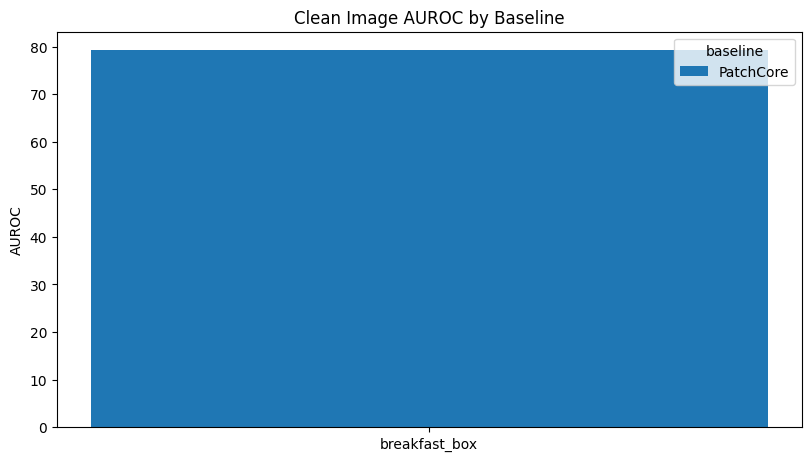

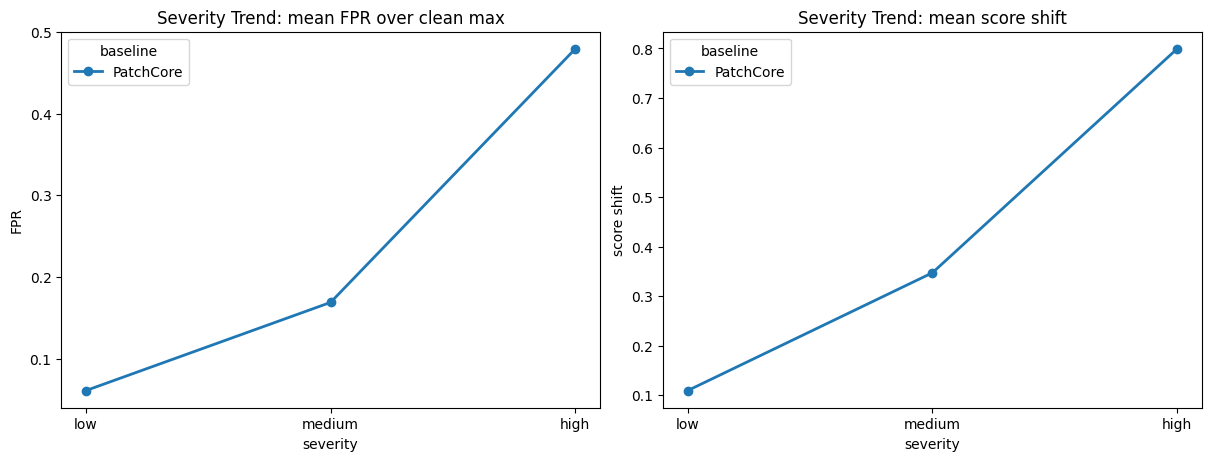

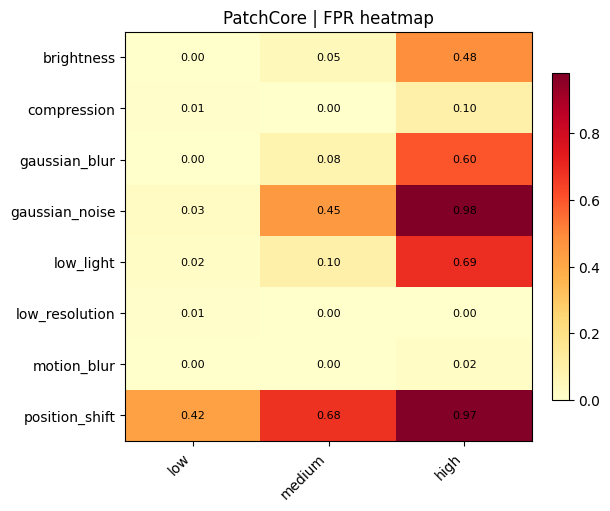

In [45]:
def build_gallery_panel(sample_row, panel_size=(160, 160)):
    image_path = Path(sample_row['image_path'])
    with Image.open(image_path) as image_obj:
        original = image_obj.convert('RGB')
    augmented = apply_augmentation(
        original.copy(),
        augmentation_type=sample_row['augmentation_type'],
        severity=sample_row['severity'],
        seed=sample_row['seed'],
        params=sample_row['params_dict'],
    )
    original_thumb = original.resize(panel_size)
    augmented_thumb = augmented.resize(panel_size)
    canvas = Image.new('RGB', (panel_size[0] * 2, panel_size[1]), color=(255, 255, 255))
    canvas.paste(original_thumb, (0, 0))
    canvas.paste(augmented_thumb, (panel_size[0], 0))
    return canvas


if clean_manifest_df.empty and shift_df.empty:
    display_title('Visual Dashboard', 'No result rows are available yet.')
else:
    display_title('Visual Dashboard', 'clean baseline, corruption summary, severity trend, score distribution shift, and corruption gallery를 그래프로 본다.')

if not clean_manifest_df.empty:
    clean_plot_df = clean_manifest_df.copy()
    baselines_in_clean = ordered_baselines(clean_plot_df['baseline'])
    categories_in_clean = list(dict.fromkeys(clean_plot_df['category']))
    x = np.arange(len(categories_in_clean))
    width = 0.8 / max(len(baselines_in_clean), 1)
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for idx, baseline in enumerate(baselines_in_clean):
        baseline_df = clean_plot_df[clean_plot_df['baseline'] == baseline].set_index('category')
        values = [baseline_df.loc[category, 'clean_image_auroc'] if category in baseline_df.index else np.nan for category in categories_in_clean]
        ax.bar(x + idx * width - ((len(baselines_in_clean) - 1) * width / 2), values, width=width, label=baseline)
    ax.set_title('Clean Image AUROC by Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(categories_in_clean, rotation=0)
    ax.set_ylabel('AUROC (%)')
    ax.legend(title='baseline')
    plt.show()

if not shift_df.empty:
    severity_line_df = shift_df.groupby(['baseline', 'category', 'shift_family', 'severity', 'severity_rank']).agg(
        shifted_normal_fpr=('shifted_normal_fpr', 'mean'),
        image_auroc_drop_from_clean=('image_auroc_drop_from_clean', 'mean'),
        mean_score_shift=('mean_score_shift', 'mean'),
        median_score_shift=('median_score_shift', 'mean'),
    ).reset_index().sort_values(['baseline', 'category', 'shift_family', 'severity_rank'])

    for (baseline, category, shift_family), family_df in severity_line_df.groupby(['baseline', 'category', 'shift_family']):
        fig, axes = plt.subplots(1, 4, figsize=(20, 4.0), constrained_layout=True)
        metric_specs = [
            ('shifted_normal_fpr', 'shifted_normal_fpr', 'FPR'),
            ('image_auroc_drop_from_clean', 'image_auroc_drop_from_clean', 'AUROC drop'),
            ('mean_score_shift', 'mean_score_shift', 'mean score shift'),
            ('median_score_shift', 'median_score_shift', 'median score shift'),
        ]
        for ax, (column, title, ylabel) in zip(axes, metric_specs):
            ax.plot(family_df['severity'], family_df[column], marker='o', linewidth=2)
            ax.set_title(f'{shift_family} | {title}')
            ax.set_xlabel('severity')
            ax.set_ylabel(ylabel)
        plt.show()

    baselines_in_shift = ordered_baselines(shift_df['baseline'])
    for metric_name, title, cmap in [
        ('shifted_normal_fpr', 'Shifted-Normal FPR heatmap', 'YlOrRd'),
        ('image_auroc_drop_from_clean', 'AUROC-drop heatmap', 'YlOrBr'),
        ('median_score_shift', 'Median score-shift heatmap', 'PuBuGn'),
    ]:
        fig, axes = plt.subplots(1, len(baselines_in_shift), figsize=(6 * len(baselines_in_shift), 5), constrained_layout=True)
        if len(baselines_in_shift) == 1:
            axes = [axes]
        for ax, baseline in zip(axes, baselines_in_shift):
            baseline_df = shift_df[shift_df['baseline'] == baseline]
            pivot = baseline_df.pivot_table(index='shift_family', columns='severity', values=metric_name, aggfunc='mean')
            ordered_cols = [column for column in ['low', 'medium', 'high'] if column in pivot.columns]
            pivot = pivot[ordered_cols]
            im = draw_heatmap(ax, pivot, f'{baseline} | {title}', cmap=cmap, value_fmt='{:.2f}')
            if im is not None:
                plt.colorbar(im, ax=ax, shrink=0.8)
        plt.show()

if not distribution_df.empty:
    display_title('Distribution Visualization', 'clean normal score distribution과 shifted normal score distribution을 corruption type별로 비교한다. shifted anomaly score는 현재 프로토콜에서 저장하지 않아 제외했다.')
    for (baseline, category, shift_family), family_df in distribution_df.groupby(['baseline', 'category', 'shift_family']):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
        boxplot_data = []
        boxplot_labels = []
        clean_scores = family_df.iloc[0]['clean_normal_scores']
        if clean_scores:
            boxplot_data.append(clean_scores)
            boxplot_labels.append('clean')
        for _, row in family_df.sort_values('severity_rank').iterrows():
            shifted_scores = row['shifted_normal_scores']
            if shifted_scores:
                boxplot_data.append(shifted_scores)
                boxplot_labels.append(row['severity'])
        if boxplot_data:
            axes[0].boxplot(boxplot_data, labels=boxplot_labels, showfliers=False)
            axes[0].set_title(f'{baseline} | {shift_family} | boxplot')
            axes[0].set_ylabel('anomaly score')
        else:
            axes[0].set_title(f'{baseline} | {shift_family} | boxplot')
            axes[0].text(0.5, 0.5, 'No score lists in summary. Re-run with updated runner.', ha='center', va='center')
            axes[0].axis('off')

        if clean_scores:
            axes[1].hist(clean_scores, bins=20, alpha=0.35, label='clean normal', density=True)
        clean_anomaly_scores = family_df.iloc[0]['clean_anomaly_scores']
        if clean_anomaly_scores:
            axes[1].hist(clean_anomaly_scores, bins=20, histtype='step', linewidth=2, label='clean anomaly', density=True)
        for _, row in family_df.sort_values('severity_rank').iterrows():
            shifted_scores = row['shifted_normal_scores']
            if shifted_scores:
                axes[1].hist(shifted_scores, bins=20, histtype='step', linewidth=2, label=f"shifted normal | {row['severity']}", density=True)
        axes[1].set_title(f'{baseline} | {shift_family} | histogram overlay')
        axes[1].set_xlabel('anomaly score')
        axes[1].set_ylabel('density')
        axes[1].legend(fontsize=8)
        plt.show()

if not gallery_df.empty:
    display_title('Corruption Gallery', '원본 clean 이미지와 corruption 적용 이미지를 나란히 두고, score와 clean 평균 대비 delta를 같이 본다.')
    gallery_display_limit = 4
    for (baseline, category, shift_family, severity), cell_df in gallery_df.groupby(['baseline', 'category', 'shift_family', 'severity']):
        display(Markdown(f'### {baseline} | {category} | {shift_family} | {severity}'))
        sample_rows = cell_df.sort_values('score', ascending=False).head(gallery_display_limit).to_dict('records')
        fig, axes = plt.subplots(len(sample_rows), 1, figsize=(8, 3.2 * max(len(sample_rows), 1)), constrained_layout=True)
        if len(sample_rows) == 1:
            axes = [axes]
        for ax, sample in zip(axes, sample_rows):
            panel = build_gallery_panel(sample)
            ax.imshow(panel)
            ax.axis('off')
            ax.set_title(
                f"score={sample['score']:.4f} | delta_from_clean_mean={sample['score_delta_from_clean_mean']:.4f} | source_id={sample['source_id']}"
            )
        plt.show()


In [46]:
if not corruption_summary_df.empty:
    summary_dashboard_df = corruption_summary_df.copy()
    summary_dashboard_df['risk_score'] = (
        summary_dashboard_df['mean_shifted_normal_fpr'].fillna(0.0)
        + summary_dashboard_df['mean_image_auroc_drop_from_clean'].fillna(0.0)
        + summary_dashboard_df['mean_score_shift'].fillna(0.0)
    )
    summary_dashboard_df = summary_dashboard_df.sort_values(['risk_score', 'worst_shifted_normal_fpr'], ascending=False).reset_index(drop=True)
else:
    summary_dashboard_df = pd.DataFrame()

display_df(
    'Summary Dashboard',
    summary_dashboard_df,
    empty_columns=['baseline', 'category', 'shift_family', 'mean_shifted_normal_fpr', 'mean_image_auroc_drop_from_clean', 'mean_score_shift'],
    body='노트북 마지막에 clean 대비 어떤 corruption이 가장 위험한지 한 번 더 압축해서 본다. 숫자가 클수록 normal false positive, AUROC drop, score shift가 동시에 큰 corruption이다.',
)

display_title('Recommended W&B Panels', 'Notebook에서 보는 질문을 W&B Runs/Compare에서도 같은 이름으로 바로 추적할 수 있게 정리했다.')
panel_specs = pd.DataFrame([
    {
        'panel_name': 'Clean image AUROC across baselines',
        'metric': 'clean_image_auroc',
        'group_by': 'group (= baseline), config.class_name',
        'notes': 'clean 환경에서 정상/이상 구분이 baseline별로 얼마나 안정적인지 본다.',
    },
    {
        'panel_name': 'Mean shifted-normal FPR',
        'metric': 'mean_shifted_normal_fpr',
        'group_by': 'group (= baseline), config.class_name',
        'notes': 'shift된 정상 샘플에서 평균적으로 얼마나 오탐하는지 본다. 네 주제의 핵심 지표다.',
    },
    {
        'panel_name': 'Worst shifted-normal FPR',
        'metric': 'worst_shifted_normal_fpr',
        'group_by': 'group (= baseline), config.class_name',
        'notes': '가장 위험한 shift cell 하나가 얼마나 크게 무너지는지 바로 찾는다.',
    },
    {
        'panel_name': 'Mean AUROC drop from clean',
        'metric': 'mean_image_auroc_drop_from_clean',
        'group_by': 'group (= baseline), config.class_name',
        'notes': 'clean 대비 discrimination이 평균적으로 얼마나 무너지는지 본다.',
    },
    {
        'panel_name': 'Severity sensitivity curves',
        'metric': 'mean_shifted_normal_fpr_by_severity/low, mean_shifted_normal_fpr_by_severity/medium, mean_shifted_normal_fpr_by_severity/high, mean_image_auroc_drop_from_clean_by_severity/low, mean_score_shift_by_severity/high',
        'group_by': 'group (= baseline)',
        'notes': 'condition severity가 올라갈수록 baseline이 얼마나 빠르게 흔들리는지 비교한다.',
    },
    {
        'panel_name': 'Shift cells detail table',
        'metric': 'shift_cells (wandb.Table)',
        'group_by': 'native table: shift, severity',
        'notes': 'cell 단위로 shifted-normal FPR, AUROC drop, mean/median score shift를 추적한다.',
    },
])
display(panel_specs)


## Recommended W&B Panels

Notebook 비교와 같은 관점을 W&B Runs/Compare에서도 그대로 볼 수 있게 추천 패널을 정리했다.

,panel_name,metric,group_by,notes
0,Clean image AUROC across baselines,clean_image_auroc,"group (= baseline), config.class_name",Clean 기준 성능이 baseline별로 얼마나 안정적인지 보는 기본 패널.
1,Worst FPR across all shift cells,worst_fpr_over_clean_max,"group (= baseline), config.class_name",어떤 baseline/category 조합이 가장 크게 무너지는지 바로 찾는다.
2,Mean FPR by severity,"mean_fpr_by_severity/low, mean_fpr_by_severity...",group (= baseline),Severity가 올라갈수록 baseline이 얼마나 빠르게 깨지는지 비교한다.
3,Shift cells detail table,shift_cells (wandb.Table),"native table: shift, severity",Notebook의 shift cell detail과 같은 단위로 원인 셀을 추적한다.
